## Closeness Metric

This notebook quantifies and evaluates the degree of alignment between the Computer Science and Information Technology courses with related job descriptions. 

In [17]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
from pathlib import Path
from collections import Counter
 
from gensim.corpora import Dictionary
from gensim.models import LdaModel

from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

In [18]:
# File Paths
BASE = Path("..").resolve()
OUT = BASE / "out"

COURSE_PATH = OUT / "dcit_courses_skills.jsonl"

CS_LOCAL_JOBS_PATH = OUT / "local_cs_skills.jsonl"
IT_LOCAL_JOBS_PATH = OUT / "local_it_skills.jsonl"

CS_INTL_JOBS_PATH = OUT / "international_cs_skills.jsonl"
IT_INTL_JOBS_PATH = OUT / "international_it_skills.jsonl"

UNRELATED_PATH = OUT / "unrelated_skills.jsonl"

AI_JOBS_PATH = OUT / "ai_skills.jsonl"

In [19]:
def normalize_multiword_skills(skills):
    if not isinstance(skills, list):
        return[]
    return [str(s).strip().replace(" ", "_") for s in skills if str(s).strip()]

def clean_tokens(tokens):
    return[
        t for t in tokens
        if t not in {"computer_science", "information_technology", "e", "case", "ar", "2d", "closing", "adding"}
    ]

def prepare_texts(records):
    texts = []
    for skills in records:
        tokens = clean_tokens(normalize_multiword_skills(skills))
        if tokens: 
            texts.append(tokens)
    return texts

In [20]:
for path in [COURSE_PATH, CS_LOCAL_JOBS_PATH, CS_INTL_JOBS_PATH,
             IT_LOCAL_JOBS_PATH, IT_INTL_JOBS_PATH,
             UNRELATED_PATH, AI_JOBS_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"{path} not found.")

# Load and split course file by thematic area
course_df       = pd.read_json(COURSE_PATH, lines=True)
course_expanded = course_df.explode("thematic_areas").rename(
    columns={"thematic_areas": "thematic_area"}
)

cs_course_texts = prepare_texts(
    course_expanded[
        course_expanded["thematic_area"] == "computer_science"
    ]["skills"].tolist()
)
it_course_texts = prepare_texts(
    course_expanded[
        course_expanded["thematic_area"] == "information_technology"
    ]["skills"].tolist()
)

cs_local_df  = pd.read_json(CS_LOCAL_JOBS_PATH, lines=True)
cs_intl_df   = pd.read_json(CS_INTL_JOBS_PATH,  lines=True)
it_local_df  = pd.read_json(IT_LOCAL_JOBS_PATH, lines=True)
it_intl_df   = pd.read_json(IT_INTL_JOBS_PATH,  lines=True)
unrelated_df = pd.read_json(UNRELATED_PATH,     lines=True)
ai_df        = pd.read_json(AI_JOBS_PATH,        lines=True)

cs_local_texts  = prepare_texts(cs_local_df["skills"].tolist())
cs_intl_texts   = prepare_texts(cs_intl_df["skills"].tolist())
it_local_texts  = prepare_texts(it_local_df["skills"].tolist())
it_intl_texts   = prepare_texts(it_intl_df["skills"].tolist())
unrelated_texts = prepare_texts(unrelated_df["skills"].tolist())
ai_texts        = prepare_texts(ai_df["skills"].tolist())

print("Record counts:")
print(f"  CS Courses   : {len(cs_course_texts)}")
print(f"  IT Courses   : {len(it_course_texts)}")
print(f"  CS Local     : {len(cs_local_texts)}")
print(f"  CS Intl      : {len(cs_intl_texts)}")
print(f"  IT Local     : {len(it_local_texts)}")
print(f"  IT Intl      : {len(it_intl_texts)}")
print(f"  AI Jobs      : {len(ai_texts)}")
print(f"  Unrelated    : {len(unrelated_texts)}")

Record counts:
  CS Courses   : 37
  IT Courses   : 31
  CS Local     : 13
  CS Intl      : 1317
  IT Local     : 13
  IT Intl      : 1353
  AI Jobs      : 1074
  Unrelated    : 1626


In [21]:
CS_NUM_TOPICS = 18
IT_NUM_TOPICS = 18

def train_lda(skills, num_topics, no_below=1, no_above=0.95):
    dictionary = Dictionary(skills)
    dictionary.filter_extremes(no_below=no_below, no_above=no_above)
    corpus = [dictionary.doc2bow(skill) for skill in skills]
    model  = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=10,
        iterations=100,
    )
    return {"dictionary": dictionary, "corpus": corpus, "model": model}


def get_topic_word_probs(model, num_topics):
    """Use full vocabulary — no artificial cap."""
    n      = len(model.id2word)
    topics = model.show_topics(
        num_topics=num_topics, num_words=n, formatted=False
    )
    return {tid: dict(wps) for tid, wps in topics}


def score_document(doc_tokens, topic_word_probs):
    word_counts  = Counter(doc_tokens)
    topic_scores = {
        tid: sum(word_counts[w] * p
                 for w, p in wps.items() if w in word_counts)
        for tid, wps in topic_word_probs.items()
    }
    best = max(topic_scores, key=topic_scores.get)
    return topic_scores[best], best, topic_scores


def compute_lda_closeness(texts, topic_word_probs):
    scores, topics = [], []
    for doc in texts:
        s, t, _ = score_document(doc, topic_word_probs)
        scores.append(s)
        topics.append(t)
    return {
        "closeness":   float(np.mean(scores)) if scores else 0.0,
        "doc_scores":  scores,
        "best_topics": topics,
    }


def compute_rho(c_jd, c_cs, c_ru):
    denom = c_cs - c_ru
    return (c_jd - c_ru) / denom if denom != 0 else 0.0


def feedback(score):
    if score > 0.7:  return "Strong Alignment"
    if score > 0.4:  return "Moderate Alignment"
    return "Weak Alignment"

In [22]:
def embed_texts(texts, model):
    """
    Join each document's skill tokens into a readable string,
    replacing underscores with spaces so the model reads
    'machine learning' not 'machine_learning'.
    """
    docs = [" ".join(doc).replace("_", " ") for doc in texts]
    return model.encode(docs, batch_size=64, convert_to_numpy=True,
                        show_progress_bar=False)


def compute_embedding_closeness(course_texts, jd_texts, embed_model):
    """Average cosine similarity between each JD and all courses."""
    course_emb = embed_texts(course_texts, embed_model)
    jd_emb     = embed_texts(jd_texts,     embed_model)
    if len(course_emb) == 0 or len(jd_emb) == 0:
        return 0.0
    sim_matrix = cosine_similarity(jd_emb, course_emb)
    return float(np.mean(sim_matrix))


def compute_embedding_alignment(course_texts, jd_texts,
                                 unrelated_texts, embed_model, label=""):
    """
    Normalised embedding alignment:
    rho = (C_JD - C_RU) / (C_CS - C_RU)
    Prints all three closeness values for transparency.
    """
    c_cs  = compute_embedding_closeness(course_texts, course_texts,  embed_model)
    c_jd  = compute_embedding_closeness(course_texts, jd_texts,      embed_model)
    c_ru  = compute_embedding_closeness(course_texts, unrelated_texts, embed_model)
    denom = c_cs - c_ru
    rho   = (c_jd - c_ru) / denom if denom != 0 else 0.0

    if label:
        print(f"\n  {label}")
        print(f"    C_CS (upper) : {c_cs:.4f}")
        print(f"    C_JD         : {c_jd:.4f}")
        print(f"    C_RU (lower) : {c_ru:.4f}")
        print(f"    rho          : {rho:.4f}  ({rho*100:.2f}%)"
              f"  [{feedback(rho)}]")

    return {"C_CS": round(c_cs,4), "C_JD": round(c_jd,4),
            "C_RU": round(c_ru,4), "rho":  round(rho,4)}

In [23]:
print("Loading sentence embedding model...")
embed_model = SentenceTransformer("all-MiniLM-L6-v2")
print("Model loaded.")

Loading sentence embedding model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1117.71it/s]


Model loaded.


# LDA Computer Science (k = 18)



Computer Science Topics:

  Topic 0: 0.006*"software_engineering" + 0.006*"source_code" + 0.006*"data_mining" + 0.006*"dataset" + 0.006*"neural_networks" + 0.006*"technical_documentation" + 0.006*"research" + 0.006*"professional_communication" + 0.006*"machine_learning" + 0.006*"machine_learn_algorithm"

  Topic 1: 0.001*"uml" + 0.001*"conceptual_model" + 0.001*"encryption" + 0.001*"security_policy" + 0.001*"human_computer_interaction" + 0.001*"process_model" + 0.001*"digital_signature" + 0.001*"teamwork" + 0.001*"access_control" + 0.001*"decision_make"

  Topic 2: 0.001*"queries_database" + 0.001*"primer" + 0.001*"performance_tuning" + 0.001*"oracle_sql" + 0.001*"oracle_server" + 0.001*"oracle_database" + 0.001*"nosql" + 0.001*"mysql" + 0.001*"learning_outcomes" + 0.001*"installation"

  Topic 3: 0.009*"operations" + 0.009*"access_control" + 0.009*"network_security" + 0.009*"presentations" + 0.009*"programming" + 0.005*"network_administrator" + 0.005*"support_engineer" + 0.005*"cisco

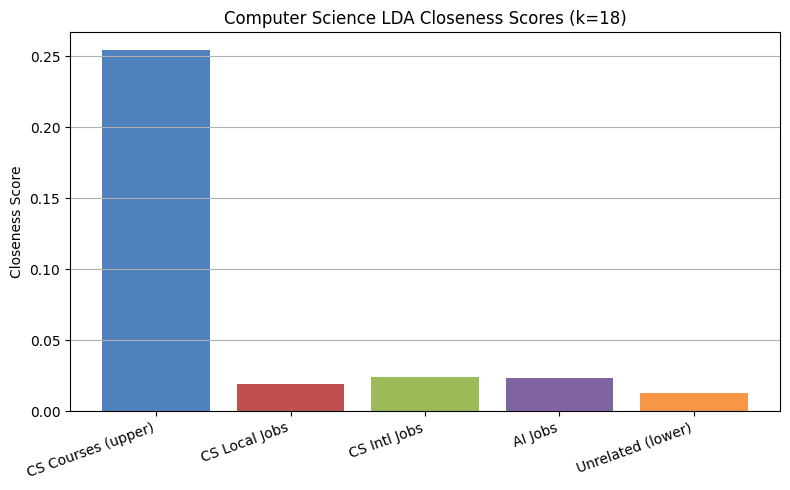

In [24]:
cs_lda = train_lda(cs_course_texts, CS_NUM_TOPICS)

print("\nComputer Science Topics:")
for topic_num, topic_words in cs_lda["model"].print_topics(num_words=10):
    print(f"\n  Topic {topic_num}: {topic_words}")
print("\n" + "=" * 60 + "\n")

cs_twp = get_topic_word_probs(cs_lda["model"], CS_NUM_TOPICS)

cs_cr  = compute_lda_closeness(cs_course_texts, cs_twp)
cs_lr  = compute_lda_closeness(cs_local_texts,  cs_twp)
cs_ir  = compute_lda_closeness(cs_intl_texts,   cs_twp)
cs_rur = compute_lda_closeness(unrelated_texts, cs_twp)
cs_air = compute_lda_closeness(ai_texts,        cs_twp)

cs_lda_rho_local = compute_rho(cs_lr["closeness"], cs_cr["closeness"], cs_rur["closeness"])
cs_lda_rho_intl  = compute_rho(cs_ir["closeness"], cs_cr["closeness"], cs_rur["closeness"])
cs_lda_rho_ai    = compute_rho(cs_air["closeness"],cs_cr["closeness"], cs_rur["closeness"])

cs_lda_results_df = pd.DataFrame([
    {"Dataset": "CS Courses (upper)", "Closeness": cs_cr["closeness"]},
    {"Dataset": "CS Local Jobs",       "Closeness": cs_lr["closeness"]},
    {"Dataset": "CS Intl Jobs",        "Closeness": cs_ir["closeness"]},
    {"Dataset": "AI Jobs",             "Closeness": cs_air["closeness"]},
    {"Dataset": "Unrelated (lower)",   "Closeness": cs_rur["closeness"]},
])
cs_lda_results_df["Closeness"] = cs_lda_results_df["Closeness"].round(4)
print(cs_lda_results_df.to_string(index=False))

cs_lda_align_df = pd.DataFrame([
    {"Dataset": "CS Local Jobs",  "LDA rho": round(cs_lda_rho_local,4), "Feedback": feedback(cs_lda_rho_local)},
    {"Dataset": "CS Intl Jobs",   "LDA rho": round(cs_lda_rho_intl, 4), "Feedback": feedback(cs_lda_rho_intl)},
    {"Dataset": "AI Jobs",        "LDA rho": round(cs_lda_rho_ai,   4), "Feedback": feedback(cs_lda_rho_ai)},
])
print("\nCS LDA Alignment Scores:")
print(cs_lda_align_df.to_string(index=False))

# Bar chart
plt.figure(figsize=(8, 5))
plt.bar(cs_lda_results_df["Dataset"], cs_lda_results_df["Closeness"],
        color=["#4F81BD","#C0504D","#9BBB59","#8064A2","#F79646"])
plt.ylabel("Closeness Score")
plt.title(f"Computer Science LDA Closeness Scores (k={CS_NUM_TOPICS})")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# LDA Information Technology (k = 18)


Information Technology Topics:

  Topic 0: 0.012*"simulations" + 0.012*"random_number_generation" + 0.012*"parameter" + 0.012*"random_numbers" + 0.006*"ipv6_address" + 0.006*"cisco" + 0.006*"ospf" + 0.006*"presentations" + 0.006*"network_topology" + 0.006*"network_administrator"

  Topic 1: 0.008*"programming" + 0.008*"scalability" + 0.008*"program_processes" + 0.008*"graphing" + 0.008*"visual_analytic" + 0.008*"mapping" + 0.008*"distributed_systems_distributed" + 0.008*"unify_communication" + 0.008*"data_storage" + 0.008*"documentation_writing"

  Topic 2: 0.013*"computer_programs" + 0.013*"data_structures" + 0.013*"algorithms" + 0.013*"information_security" + 0.007*"management" + 0.007*"operations" + 0.007*"reliability" + 0.007*"password_authentication" + 0.007*"library_linking" + 0.007*"public_key_infrastructure"

  Topic 3: 0.008*"collaboration_communication" + 0.008*"process_functionality" + 0.008*"teamwork" + 0.008*"human_system" + 0.008*"electronic_designs" + 0.008*"human_inter

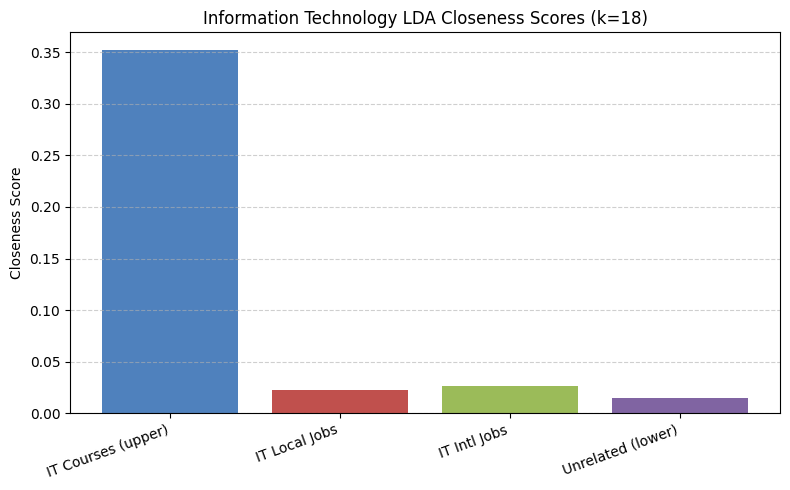

In [25]:
it_lda = train_lda(it_course_texts, IT_NUM_TOPICS)

print("\nInformation Technology Topics:")
for topic_num, topic_words in it_lda["model"].print_topics(num_words=10):
    print(f"\n  Topic {topic_num}: {topic_words}")
print("\n" + "=" * 60 + "\n")

it_twp = get_topic_word_probs(it_lda["model"], IT_NUM_TOPICS)

it_cr  = compute_lda_closeness(it_course_texts, it_twp)
it_lr  = compute_lda_closeness(it_local_texts,  it_twp)
it_ir  = compute_lda_closeness(it_intl_texts,   it_twp)
it_rur = compute_lda_closeness(unrelated_texts, it_twp)

it_lda_rho_local = compute_rho(it_lr["closeness"], it_cr["closeness"], it_rur["closeness"])
it_lda_rho_intl  = compute_rho(it_ir["closeness"], it_cr["closeness"], it_rur["closeness"])

it_lda_results_df = pd.DataFrame([
    {"Dataset": "IT Courses (upper)", "Closeness": it_cr["closeness"]},
    {"Dataset": "IT Local Jobs",       "Closeness": it_lr["closeness"]},
    {"Dataset": "IT Intl Jobs",        "Closeness": it_ir["closeness"]},
    {"Dataset": "Unrelated (lower)",   "Closeness": it_rur["closeness"]},
])
it_lda_results_df["Closeness"] = it_lda_results_df["Closeness"].round(4)
print(it_lda_results_df.to_string(index=False))

it_lda_align_df = pd.DataFrame([
    {"Dataset": "IT Local Jobs", "LDA rho": round(it_lda_rho_local,4), "Feedback": feedback(it_lda_rho_local)},
    {"Dataset": "IT Intl Jobs",  "LDA rho": round(it_lda_rho_intl, 4), "Feedback": feedback(it_lda_rho_intl)},
])
print("\nIT LDA Alignment Scores:")
print(it_lda_align_df.to_string(index=False))

# Bar chart
plt.figure(figsize=(8, 5))
plt.bar(it_lda_results_df["Dataset"], it_lda_results_df["Closeness"],
        color=["#4F81BD","#C0504D","#9BBB59","#8064A2"])
plt.ylabel("Closeness Score")
plt.title(f"Information Technology LDA Closeness Scores (k={IT_NUM_TOPICS})")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# LDA Weighted rho_w

In [26]:
n_cs_local = len(cs_local_texts)
n_cs_intl  = len(cs_intl_texts)
n_it_local = len(it_local_texts)
n_it_intl  = len(it_intl_texts)

lda_rho_w_local = (
    (cs_lda_rho_local * n_cs_local) + (it_lda_rho_local * n_it_local)
) / (n_cs_local + n_it_local)

lda_rho_w_intl = (
    (cs_lda_rho_intl * n_cs_intl) + (it_lda_rho_intl * n_it_intl)
) / (n_cs_intl + n_it_intl)

lda_rho_w_overall = (
    (cs_lda_rho_local * n_cs_local) + (cs_lda_rho_intl * n_cs_intl) +
    (it_lda_rho_local * n_it_local) + (it_lda_rho_intl * n_it_intl)
) / (n_cs_local + n_cs_intl + n_it_local + n_it_intl)

lda_weighted_df = pd.DataFrame([
    {"Programme": "Computer Science",       "LDA rho Caribbean": round(cs_lda_rho_local,4), "LDA rho International": round(cs_lda_rho_intl,4)},
    {"Programme": "Information Technology", "LDA rho Caribbean": round(it_lda_rho_local,4), "LDA rho International": round(it_lda_rho_intl,4)},
    {"Programme": "Weighted rho_w",         "LDA rho Caribbean": round(lda_rho_w_local,4),  "LDA rho International": round(lda_rho_w_intl,4)},
])
print("\nLDA Weighted Alignment Scores (rho_w)")
print("=" * 55)
print(lda_weighted_df.to_string(index=False))
print(f"\nOverall weighted rho_w: {lda_rho_w_overall:.4f}")


LDA Weighted Alignment Scores (rho_w)
             Programme  LDA rho Caribbean  LDA rho International
      Computer Science             0.0256                 0.0483
Information Technology             0.0225                 0.0346
        Weighted rho_w             0.0241                 0.0413

Overall weighted rho_w: 0.0412


# Semantic Embedding for Computer Science 

In [27]:
cs_emb_local = compute_embedding_alignment(
    cs_course_texts, cs_local_texts, unrelated_texts,
    embed_model, label="CS Caribbean"
)
cs_emb_intl = compute_embedding_alignment(
    cs_course_texts, cs_intl_texts, unrelated_texts,
    embed_model, label="CS International"
)
cs_emb_ai = compute_embedding_alignment(
    cs_course_texts, ai_texts, unrelated_texts,
    embed_model, label="CS AI Jobs"
)


  CS Caribbean
    C_CS (upper) : 0.4243
    C_JD         : 0.2808
    C_RU (lower) : 0.2175
    rho          : 0.3061  (30.61%)  [Weak Alignment]

  CS International
    C_CS (upper) : 0.4243
    C_JD         : 0.3330
    C_RU (lower) : 0.2175
    rho          : 0.5585  (55.85%)  [Moderate Alignment]

  CS AI Jobs
    C_CS (upper) : 0.4243
    C_JD         : 0.3566
    C_RU (lower) : 0.2175
    rho          : 0.6725  (67.25%)  [Moderate Alignment]


# Semantic Embedding for Information Technology

In [28]:
it_emb_local = compute_embedding_alignment(
    it_course_texts, it_local_texts, unrelated_texts,
    embed_model, label="IT Caribbean"
)
it_emb_intl = compute_embedding_alignment(
    it_course_texts, it_intl_texts, unrelated_texts,
    embed_model, label="IT International"
)


  IT Caribbean
    C_CS (upper) : 0.4582
    C_JD         : 0.2943
    C_RU (lower) : 0.2316
    rho          : 0.2767  (27.67%)  [Weak Alignment]

  IT International
    C_CS (upper) : 0.4582
    C_JD         : 0.3570
    C_RU (lower) : 0.2316
    rho          : 0.5535  (55.35%)  [Moderate Alignment]


# Comparsion 

In [29]:
comparison_df = pd.DataFrame([
    {
        "Programme":         "CS Caribbean",
        "LDA rho":           round(cs_lda_rho_local, 4),
        "LDA Feedback":      feedback(cs_lda_rho_local),
        "Embedding rho":     cs_emb_local["rho"],
        "Embed Feedback":    feedback(cs_emb_local["rho"]),
    },
    {
        "Programme":         "CS International",
        "LDA rho":           round(cs_lda_rho_intl, 4),
        "LDA Feedback":      feedback(cs_lda_rho_intl),
        "Embedding rho":     cs_emb_intl["rho"],
        "Embed Feedback":    feedback(cs_emb_intl["rho"]),
    },
    {
        "Programme":         "CS AI Jobs",
        "LDA rho":           round(cs_lda_rho_ai, 4),
        "LDA Feedback":      feedback(cs_lda_rho_ai),
        "Embedding rho":     cs_emb_ai["rho"],
        "Embed Feedback":    feedback(cs_emb_ai["rho"]),
    },
    {
        "Programme":         "IT Caribbean",
        "LDA rho":           round(it_lda_rho_local, 4),
        "LDA Feedback":      feedback(it_lda_rho_local),
        "Embedding rho":     it_emb_local["rho"],
        "Embed Feedback":    feedback(it_emb_local["rho"]),
    },
    {
        "Programme":         "IT International",
        "LDA rho":           round(it_lda_rho_intl, 4),
        "LDA Feedback":      feedback(it_lda_rho_intl),
        "Embedding rho":     it_emb_intl["rho"],
        "Embed Feedback":    feedback(it_emb_intl["rho"]),
    },
])

print("\nFinal Comparison: LDA vs Semantic Embedding")
print("=" * 70)
print(comparison_df.to_string(index=False))


Final Comparison: LDA vs Semantic Embedding
       Programme  LDA rho   LDA Feedback  Embedding rho     Embed Feedback
    CS Caribbean   0.0256 Weak Alignment         0.3061     Weak Alignment
CS International   0.0483 Weak Alignment         0.5585 Moderate Alignment
      CS AI Jobs   0.0436 Weak Alignment         0.6725 Moderate Alignment
    IT Caribbean   0.0225 Weak Alignment         0.2767     Weak Alignment
IT International   0.0346 Weak Alignment         0.5535 Moderate Alignment


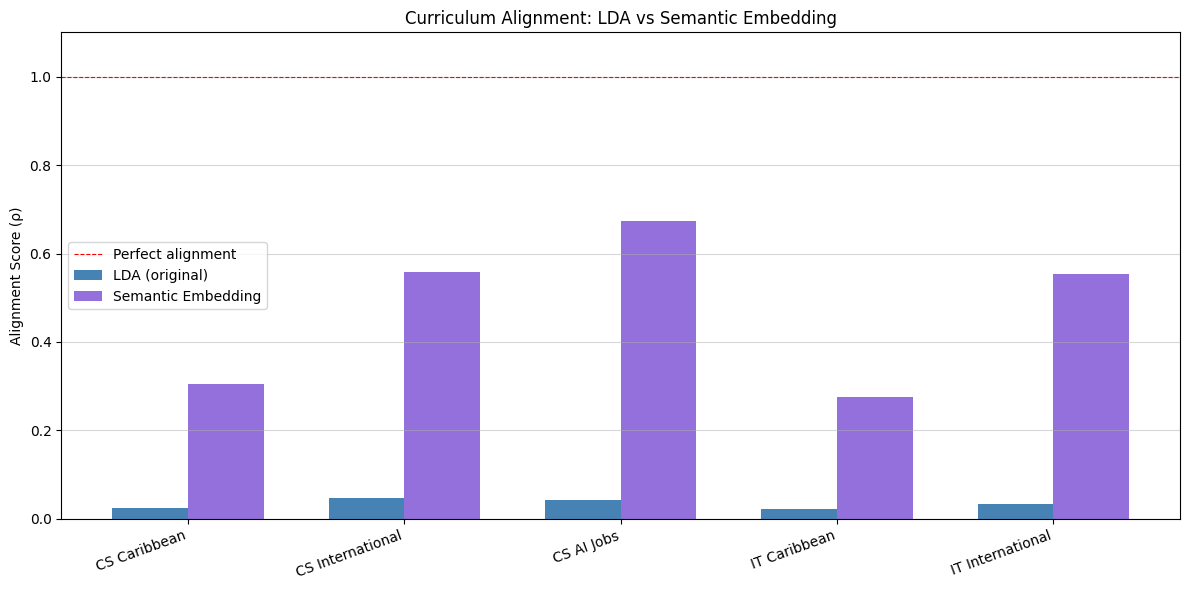

In [30]:
labels = comparison_df["Programme"].tolist()
x      = np.arange(len(labels))
width  = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, comparison_df["LDA rho"],       width,
       label="LDA (original)",    color="steelblue")
ax.bar(x + width/2, comparison_df["Embedding rho"], width,
       label="Semantic Embedding", color="mediumpurple")

ax.axhline(y=1.0, color="red", linestyle="--",
           linewidth=0.8, label="Perfect alignment")
ax.set_ylabel("Alignment Score (ρ)")
ax.set_title("Curriculum Alignment: LDA vs Semantic Embedding")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.5)
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()